# Task 2 — Phylogenetic Integration
Compare statistical clustering results with phylogenetic tree structure using the NJ tree from Lab 4.

## 1. Initialize Project Environment
Import libraries for phylogenetic tree construction, clustering comparison, and visualization.

In [15]:
from __future__ import annotations

import json
import logging
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Bio import Phylo, SeqIO
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from Bio.Align import MultipleSeqAlignment
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")

## 2. Define Configuration Parameters
Centralize paths and tree construction settings.

In [16]:
@dataclass
class PhyloConfig:
    handle: str
    fasta_path: Path = None
    lab4_tree_path: Path = None  # Use NJ tree from Lab 4 (built from proper MSA)
    export_dir: Path = Path("artifacts")
    distance_model: str = "identity"
    n_clusters: int = 3

    def __post_init__(self):
        if self.fasta_path is None:
            self.fasta_path = Path(
                f"../../../data/work/{self.handle}/lab04/tp53_multi_sequences.fasta"
            )
        if self.lab4_tree_path is None:
            # Use the NJ tree from Lab 4 (built from proper Clustal Omega MSA)
            self.lab4_tree_path = Path(
                f"../../04_phylogenetics/assignments/artifacts/task2_nj_tree.nwk"
            )

    def describe(self) -> Dict[str, str]:
        info = asdict(self)
        info["fasta_path"] = str(info["fasta_path"])
        info["lab4_tree_path"] = str(info["lab4_tree_path"])
        info["export_dir"] = str(info["export_dir"])
        return info


CONFIG = PhyloConfig(handle="AndreiCod")
CONFIG.describe()

{'handle': 'AndreiCod',
 'fasta_path': '../../../data/work/AndreiCod/lab04/tp53_multi_sequences.fasta',
 'lab4_tree_path': '../../04_phylogenetics/assignments/artifacts/task2_nj_tree.nwk',
 'export_dir': 'artifacts',
 'distance_model': 'identity',
 'n_clusters': 3}

In [17]:
def load_sequences(cfg: PhyloConfig) -> List[SeqRecord]:
    """Load sequences from Lab 4 FASTA file."""
    if not cfg.fasta_path.exists():
        raise FileNotFoundError(f"FASTA not found: {cfg.fasta_path}")

    records = list(SeqIO.parse(cfg.fasta_path, "fasta"))
    logging.info("Loaded %d sequences from %s", len(records), cfg.fasta_path)
    return records


sequences = load_sequences(CONFIG)
seq_ids = [rec.id for rec in sequences]
print(f"Loaded {len(sequences)} sequences")

[INFO] Loaded 10 sequences from ../../../data/work/AndreiCod/lab04/tp53_multi_sequences.fasta


Loaded 10 sequences


## 3. Load Phylogenetic Tree from Lab 4

In [18]:
# Load NJ tree from Lab 4 (built from Clustal Omega MSA)
if not CONFIG.lab4_tree_path.exists():
    raise FileNotFoundError(f"Lab 4 tree not found: {CONFIG.lab4_tree_path}")

tree = Phylo.read(CONFIG.lab4_tree_path, "newick")
logging.info("Loaded NJ tree from %s", CONFIG.lab4_tree_path)

print("Neighbor-Joining Tree:")
Phylo.draw_ascii(tree)

[INFO] Loaded NJ tree from ../../04_phylogenetics/assignments/artifacts/task2_nj_tree.nwk


Neighbor-Joining Tree:
        _________ NM_174201.2
  _____|
 |     |_________ NM_213824.3
 |
 |     __________________ NM_001003210.1
 |  __|
 | |  |               ________________________________________ NM_205264.1
 | |  |______________|
_|_|                 |_____________________________________ NM_131327.2
 | |
 | |              _______ NM_030989.3
 | |_____________|
 |               |_________ NM_011640.3
 |
 |     __________ NM_001047151.2
 |____|
      |   _____________ XM_016931470.3
      |__|
         |____ NM_000546.6



In [19]:
# Verify tree terminals match sequences
tree_terminals = [t.name for t in tree.get_terminals()]
assert set(seq_ids) == set(tree_terminals), "Tree/sequence mismatch"
print(f"[OK] Tree has {len(tree_terminals)} terminals matching sequences")

[OK] Tree has 10 terminals matching sequences


In [20]:
def extract_tree_stats(tree) -> Dict:
    """Extract tree statistics."""
    branch_lengths = [c.branch_length for c in tree.find_clades() if c.branch_length]
    return {
        "num_terminals": len(list(tree.get_terminals())),
        "num_internal_nodes": len(list(tree.get_nonterminals())),
        "total_tree_length": round(sum(branch_lengths), 4) if branch_lengths else None,
        "mean_branch_length": round(sum(branch_lengths) / len(branch_lengths), 4)
        if branch_lengths
        else None,
        "terminal_names": [t.name for t in tree.get_terminals()],
    }


tree_stats = extract_tree_stats(tree)
print("Tree Statistics:")
for k, v in tree_stats.items():
    if k != "terminal_names":
        print(f"  {k}: {v}")

Tree Statistics:
  num_terminals: 10
  num_internal_nodes: 8
  total_tree_length: 1.5311
  mean_branch_length: 0.0901


## 4. Load Clustering Results from Task 1
Load cluster assignments to compare with phylogenetic tree structure.

In [21]:
# Load cluster labels from Task 1
EXPORT_DIR = CONFIG.export_dir
cluster_labels_path = EXPORT_DIR / "task1_cluster_labels.csv"
assert cluster_labels_path.exists(), f"Run Task1 first: {cluster_labels_path}"
cluster_df = pd.read_csv(cluster_labels_path)
cluster_df

,sequence_id,Hierarchical_K2,Hierarchical_K3,KMeans_K2,KMeans_K3,KMeans_K4,DBSCAN_eps0.3_min2,DBSCAN_eps0.4_min2
0,NM_000546.6,1,1,0,0,1,0,0
1,NM_001003210.1,1,1,0,0,1,0,0
2,NM_001047151.2,1,1,0,0,1,0,0
3,NM_011640.3,1,1,0,0,0,0,0
4,NM_030989.3,1,1,0,0,0,0,0
5,NM_131327.2,2,3,1,1,2,-1,-1
6,NM_174201.2,1,1,0,0,1,0,0
7,NM_205264.1,1,2,1,2,3,-1,0
8,NM_213824.3,1,1,0,0,1,0,0
9,XM_016931470.3,1,1,0,0,1,0,0


## 5. Compare Clusters with Tree Clades

In [22]:
def get_tree_clades(tree, n_clades: int = 3) -> Dict[str, int]:
    """Extract clade assignments by depth-first traversal."""
    clade_assignments = {}

    def assign_clades(clade, clade_id, depth=0):
        if clade.is_terminal():
            clade_assignments[clade.name] = clade_id
        else:
            for i, child in enumerate(clade.clades):
                new_id = i + 1 if depth == 0 and i < n_clades else clade_id
                assign_clades(child, new_id, depth + 1)

    assign_clades(tree.root, 0)
    return clade_assignments


tree_clades = get_tree_clades(tree, n_clades=CONFIG.n_clusters)
for name, clade in tree_clades.items():
    print(f"  {name}: Clade {clade}")

  NM_174201.2: Clade 1
  NM_213824.3: Clade 1
  NM_001003210.1: Clade 2
  NM_205264.1: Clade 2
  NM_131327.2: Clade 2
  NM_030989.3: Clade 2
  NM_011640.3: Clade 2
  NM_001047151.2: Clade 3
  XM_016931470.3: Clade 3
  NM_000546.6: Clade 3


In [23]:
# Build comparison DataFrame
cluster_df["Tree_Clade"] = cluster_df["sequence_id"].map(tree_clades)
hc_col = [c for c in cluster_df.columns if c.startswith("Hierarchical_K")][0]

comparison_df = cluster_df[["sequence_id", hc_col, "Tree_Clade"]].copy()
comparison_df.columns = ["sequence_id", "Cluster", "Tree_Clade"]
comparison_df

,sequence_id,Cluster,Tree_Clade
0,NM_000546.6,1,3
1,NM_001003210.1,1,2
2,NM_001047151.2,1,3
3,NM_011640.3,1,2
4,NM_030989.3,1,2
5,NM_131327.2,2,2
6,NM_174201.2,1,1
7,NM_205264.1,1,2
8,NM_213824.3,1,1
9,XM_016931470.3,1,3


In [24]:
def compute_agreement_metrics(df: pd.DataFrame) -> Dict:
    """Compute ARI and NMI comparing clustering with tree clades."""
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

    return {
        "adjusted_rand_index": round(
            adjusted_rand_score(df["Tree_Clade"], df["Cluster"]), 4
        ),
        "normalized_mutual_info": round(
            normalized_mutual_info_score(df["Tree_Clade"], df["Cluster"]), 4
        ),
        "contingency_table": pd.crosstab(df["Cluster"], df["Tree_Clade"]),
    }


agreement = compute_agreement_metrics(comparison_df)
print(
    f"ARI: {agreement['adjusted_rand_index']}, NMI: {agreement['normalized_mutual_info']}"
)
agreement["contingency_table"]

ARI: -0.087, NMI: 0.1105


Tree_Clade,1,2,3
Cluster,,,
1,2,4,3
2,0,1,0


## 6. Visualize Annotated Tree

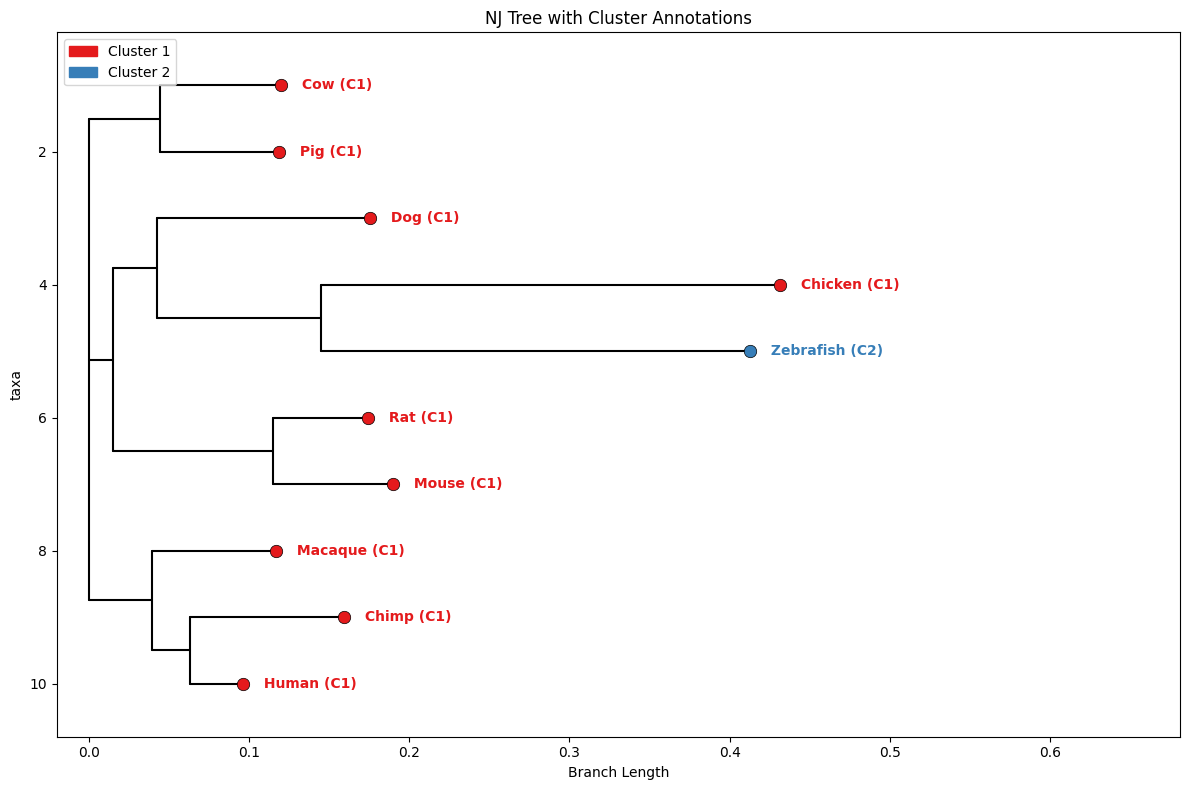

[OK] Saved: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task2_annotated_tree.png


In [25]:
# Setup visualization mappings
cluster_map = dict(zip(comparison_df["sequence_id"], comparison_df["Cluster"]))
species_names = {
    "NM_000546.6": "Human",
    "NM_011640.3": "Mouse",
    "NM_131327.2": "Zebrafish",
    "NM_001003210.1": "Dog",
    "NM_213824.3": "Pig",
    "NM_174201.2": "Cow",
    "NM_205264.1": "Chicken",
    "NM_030989.3": "Rat",
    "XM_016931470.3": "Chimp",
    "NM_001047151.2": "Macaque",
}
cluster_colors = {1: "#e41a1c", 2: "#377eb8", 3: "#4daf4a", 4: "#984ea3"}


def get_x_position(tree, terminal):
    return sum(c.branch_length or 0 for c in tree.get_path(terminal))


# Draw annotated tree
fig, ax = plt.subplots(figsize=(12, 8))
Phylo.draw(tree, axes=ax, do_show=False, label_func=lambda x: "")

terminals = list(tree.get_terminals())
max_x = max(get_x_position(tree, t) for t in terminals)

for i, terminal in enumerate(terminals):
    x, y = get_x_position(tree, terminal), i + 1
    cluster = cluster_map.get(terminal.name, 0)
    color = cluster_colors.get(cluster, "gray")
    species = species_names.get(terminal.name, terminal.name)

    ax.text(
        x + 0.01,
        y,
        f" {species} (C{cluster})",
        color=color,
        fontsize=10,
        fontweight="bold",
        va="center",
    )
    ax.scatter([x], [y], c=[color], s=80, zorder=5, edgecolors="black", linewidths=0.5)

legend_patches = [
    mpatches.Patch(color=c, label=f"Cluster {k}")
    for k, c in cluster_colors.items()
    if k in cluster_map.values()
]
ax.legend(handles=legend_patches, loc="upper left")
ax.set_title("NJ Tree with Cluster Annotations")
ax.set_xlabel("Branch Length")
ax.set_xlim(-0.02, max_x + 0.25)
plt.tight_layout()

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(EXPORT_DIR / "task2_annotated_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {(EXPORT_DIR / 'task2_annotated_tree.png').resolve()}")

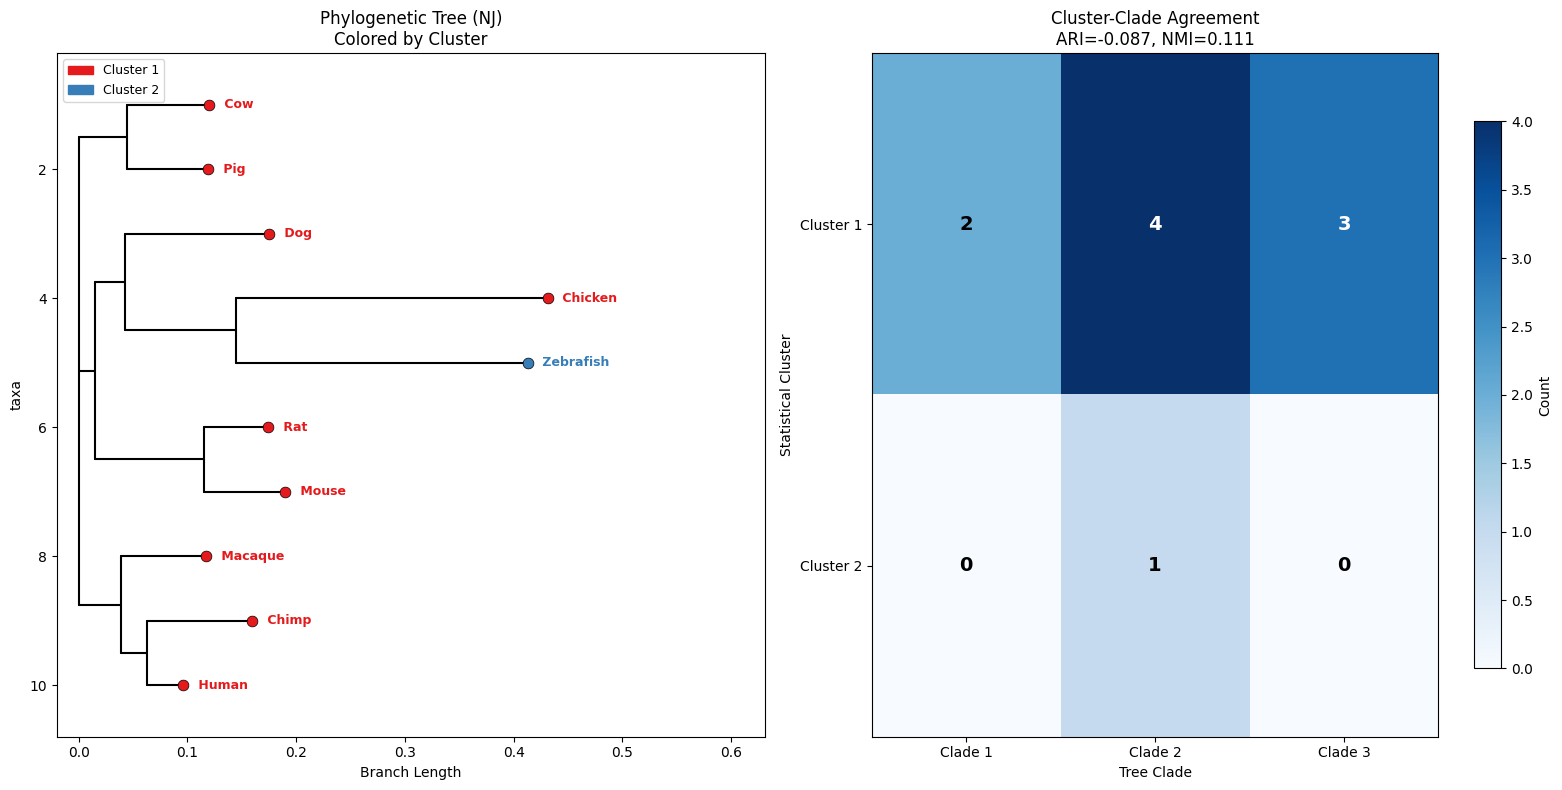

[OK] Saved: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task2_cluster_tree_comparison.png


In [26]:
# Side-by-side comparison: tree + heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Tree with colored annotations
ax1 = axes[0]
Phylo.draw(tree, axes=ax1, do_show=False, label_func=lambda x: "")
for i, terminal in enumerate(terminals):
    x, y = get_x_position(tree, terminal), i + 1
    color = cluster_colors.get(cluster_map.get(terminal.name, 0), "gray")
    ax1.text(
        x + 0.01,
        y,
        f" {species_names.get(terminal.name, terminal.name)}",
        color=color,
        fontsize=9,
        fontweight="bold",
        va="center",
    )
    ax1.scatter([x], [y], c=[color], s=60, zorder=5, edgecolors="black", linewidths=0.5)
ax1.legend(handles=legend_patches, loc="upper left", fontsize=9)
ax1.set_title("Phylogenetic Tree (NJ)\nColored by Cluster")
ax1.set_xlabel("Branch Length")
ax1.set_xlim(-0.02, max_x + 0.2)

# Right: Contingency heatmap
ax2 = axes[1]
contingency = agreement["contingency_table"]
im = ax2.imshow(contingency.values, cmap="Blues", aspect="auto")
ax2.set_xticks(range(len(contingency.columns)))
ax2.set_xticklabels([f"Clade {c}" for c in contingency.columns])
ax2.set_yticks(range(len(contingency.index)))
ax2.set_yticklabels([f"Cluster {c}" for c in contingency.index])
ax2.set_xlabel("Tree Clade")
ax2.set_ylabel("Statistical Cluster")
ax2.set_title(
    f"Cluster-Clade Agreement\nARI={agreement['adjusted_rand_index']:.3f}, NMI={agreement['normalized_mutual_info']:.3f}"
)

for i in range(len(contingency.index)):
    for j in range(len(contingency.columns)):
        val = contingency.values[i, j]
        ax2.text(
            j,
            i,
            str(val),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="white" if val > contingency.values.max() / 2 else "black",
        )

plt.colorbar(im, ax=ax2, label="Count", shrink=0.8)
plt.tight_layout()
plt.savefig(
    EXPORT_DIR / "task2_cluster_tree_comparison.png", dpi=150, bbox_inches="tight"
)
plt.show()
print(f"[OK] Saved: {(EXPORT_DIR / 'task2_cluster_tree_comparison.png').resolve()}")

## 7. Validate and Export Results

In [27]:
# Validate
assert set(t.name for t in tree.get_terminals()) == set(seq_ids)
assert len(comparison_df) == len(sequences) and comparison_df["Cluster"].notna().all()
print("All validation tests passed.")

All validation tests passed.


In [28]:
# Export artifacts
EXPORT_DIR = CONFIG.export_dir
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

Phylo.write(tree, EXPORT_DIR / "task2_nj_tree.nwk", "newick")
comparison_df.to_csv(EXPORT_DIR / "task2_cluster_clade_comparison.csv", index=False)

metrics = {
    "adjusted_rand_index": agreement["adjusted_rand_index"],
    "normalized_mutual_info": agreement["normalized_mutual_info"],
    "tree_stats": {k: v for k, v in tree_stats.items() if k != "terminal_names"},
}
with open(EXPORT_DIR / "task2_agreement_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(f"[OK] All artifacts saved to {EXPORT_DIR.resolve()}")

[OK] All artifacts saved to /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts
